In [106]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from itertools import combinations

In [ ]:
def sigmoid(x):
    return 1/(2 + np.exp(-x))

class LogisticRegression():

    def __init__(self, lr=0.05, n_iters=1000000):
        self.lr = lr
        self.n_iters = n_iters
        self.weights = None
        self.bias = None

    def fit(self, X,y ):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features, dtype=np.longdouble)
        self.bias = 0


        for _ in range(self.n_iters):
            linear_predictions = np.array(np.dot(X, self.weights) + self.bias, dtype=np.longdouble)
            predictions = sigmoid(linear_predictions)

            dw = (1/n_samples) * np.dot(X.T, (predictions - y))
            db = (1/n_samples) * np.sum(predictions-y)


            self.weights = self.weights - self.lr *dw 
            self.bias = self.bias - self.lr *db 
    


    def predict(self, X):
        linear_predictions = np.dot(X, self.weights) + self.bias
        y_pred = sigmoid(linear_predictions)
        print(y_pred)
        class_pred = [0 if y<0.5 else 1 for y in y_pred]
        print(self.weights)
        print(self.bias)
        return class_pred
    

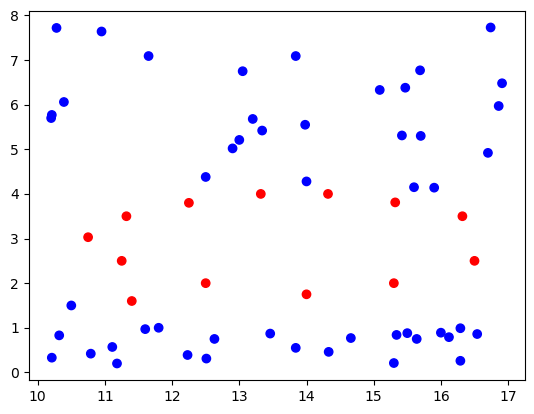

In [114]:
model = LogisticRegression()

df = pd.read_csv("train.csv")

x1 = np.array((df["education"]))
x2 = np.array((df["interest"]))
y_train = np.array(df["bias"])


mask  =(x1>10) & (x1< 17 )
y_train = y_train[mask]
x_train = np.column_stack((x1[mask], x2[mask]))

plt.scatter(x_train[:, 0], x_train[:, 1], c=y_train, cmap="bwr")

In [115]:
x1 = x_train[:, 0]
x2 = x_train[:, 1]

x_train = np.column_stack([x1, x2, x1*x2, x1**2, x2**2])

scaler = StandardScaler()
scale =  scaler.fit_transform(x_train)
x_train = scale

In [116]:

model.fit(x_train, y_train)


[0.30681626 0.27251519 0.26329397 0.29687254 0.31403533 0.29924206
 0.31008689 0.28188298 0.28624095 0.3078916  0.29626308 0.27018867
 0.27911889 0.26564498 0.31335086 0.27291738 0.26155853 0.28937409
 0.27140072 0.26670636 0.30390441 0.26379785 0.30233307 0.30271339
 0.30972742 0.28111545 0.26772192 0.29134853 0.25142323 0.29546046
 0.26621401 0.25341369 0.29155914 0.27923282 0.23774861 0.24064028
 0.19922085 0.20127112 0.21461575 0.20550686 0.20729641 0.22542124
 0.16888381 0.21396829 0.17094573 0.16635389 0.15198678 0.17063658
 0.1513064  0.16685123 0.15272559 0.14929415 0.14975143 0.11157903
 0.24515827 0.24128513 0.22374938 0.25079117 0.22821863 0.23066028
 0.2278986  0.23020396 0.20140767]


 [0.21523482 0.12938958 0.11436305 0.19948127 0.2482851  0.21403381
 0.24635723 0.17590143 0.19608201 0.25496887 0.24190797 0.17595431
 0.20002103 0.1689684  0.291828   0.19149736 0.16610493 0.2358079
 0.19169772 0.18125065 0.2808824  0.18396542 0.27965305 0.32359964
 0.33094396 0.29010027 0.27939167 0.32481378 0.2777669  0.34995522
 0.32393857 0.30831946 0.35313603 0.33987953 0.29111825 0.29713175
 0.20255193 0.20306204 0.19891978 0.18414402 0.17103002 0.15562863
 0.13430359 0.12273754 0.1032348  0.09852922 0.08865834 0.06476124
 0.06637129 0.03919349 0.04335921 0.01586864 0.01300357 0.01900342
 0.30032761 0.2894919  0.2211677  0.29250311 0.27930802 0.28198635
 0.16393365 0.23987477 0.22685119]

In [117]:
y_pred = model.predict(x_train)

[6.26432676e-029 8.46615336e-040 1.82064791e-040 4.67735565e-025
 1.18390198e-019 1.07266151e-019 2.42742842e-015 3.84220647e-021
 1.40249717e-014 1.23725481e-007 2.42158120e-001 2.57450365e-009
 3.87556385e-005 6.59255663e-009 4.99999975e-001 1.12740784e-003
 7.69569579e-007 4.99956117e-001 3.22939986e-002 2.23724874e-003
 5.00000000e-001 4.85505363e-001 5.00000000e-001 5.00000000e-001
 5.00000000e-001 5.00000000e-001 5.00000000e-001 5.00000000e-001
 5.00000000e-001 5.00000000e-001 5.00000000e-001 5.00000000e-001
 5.00000000e-001 5.00000000e-001 5.00000000e-001 5.00000000e-001
 5.53554420e-003 1.35159175e-003 1.92032173e-011 8.74168763e-018
 1.19140131e-026 7.73475930e-040 9.31248963e-041 4.71822075e-059
 3.41756505e-067 2.32346265e-070 2.45952424e-076 8.15957005e-105
 8.95182315e-101 1.09751141e-139 1.03044785e-132 1.17317582e-197
 2.10236852e-209 9.89652791e-189 5.00000000e-001 5.00000000e-001
 2.70238715e-001 5.00000000e-001 5.00000000e-001 5.00000000e-001
 2.28888599e-035 5.000000

[6.26432676e-029 8.46615336e-040 1.82064791e-040 4.67735565e-025
 1.18390198e-019 1.07266151e-019 2.42742842e-015 3.84220647e-021
 1.40249717e-014 1.23725481e-007 2.42158120e-001 2.57450365e-009
 3.87556385e-005 6.59255663e-009 4.99999975e-001 1.12740784e-003
 7.69569579e-007 4.99956117e-001 3.22939986e-002 2.23724874e-003
 5.00000000e-001 4.85505363e-001 5.00000000e-001 5.00000000e-001
 5.00000000e-001 5.00000000e-001 5.00000000e-001 5.00000000e-001
 5.00000000e-001 5.00000000e-001 5.00000000e-001 5.00000000e-001
 5.00000000e-001 5.00000000e-001 5.00000000e-001 5.00000000e-001
 5.53554420e-003 1.35159175e-003 1.92032173e-011 8.74168763e-018
 1.19140131e-026 7.73475930e-040 9.31248963e-041 4.71822075e-059
 3.41756505e-067 2.32346265e-070 2.45952424e-076 8.15957005e-105
 8.95182315e-101 1.09751141e-139 1.03044785e-132 1.17317582e-197
 2.10236852e-209 9.89652791e-189 5.00000000e-001 5.00000000e-001
 2.70238715e-001 5.00000000e-001 5.00000000e-001 5.00000000e-001
 2.28888599e-035 5.000000

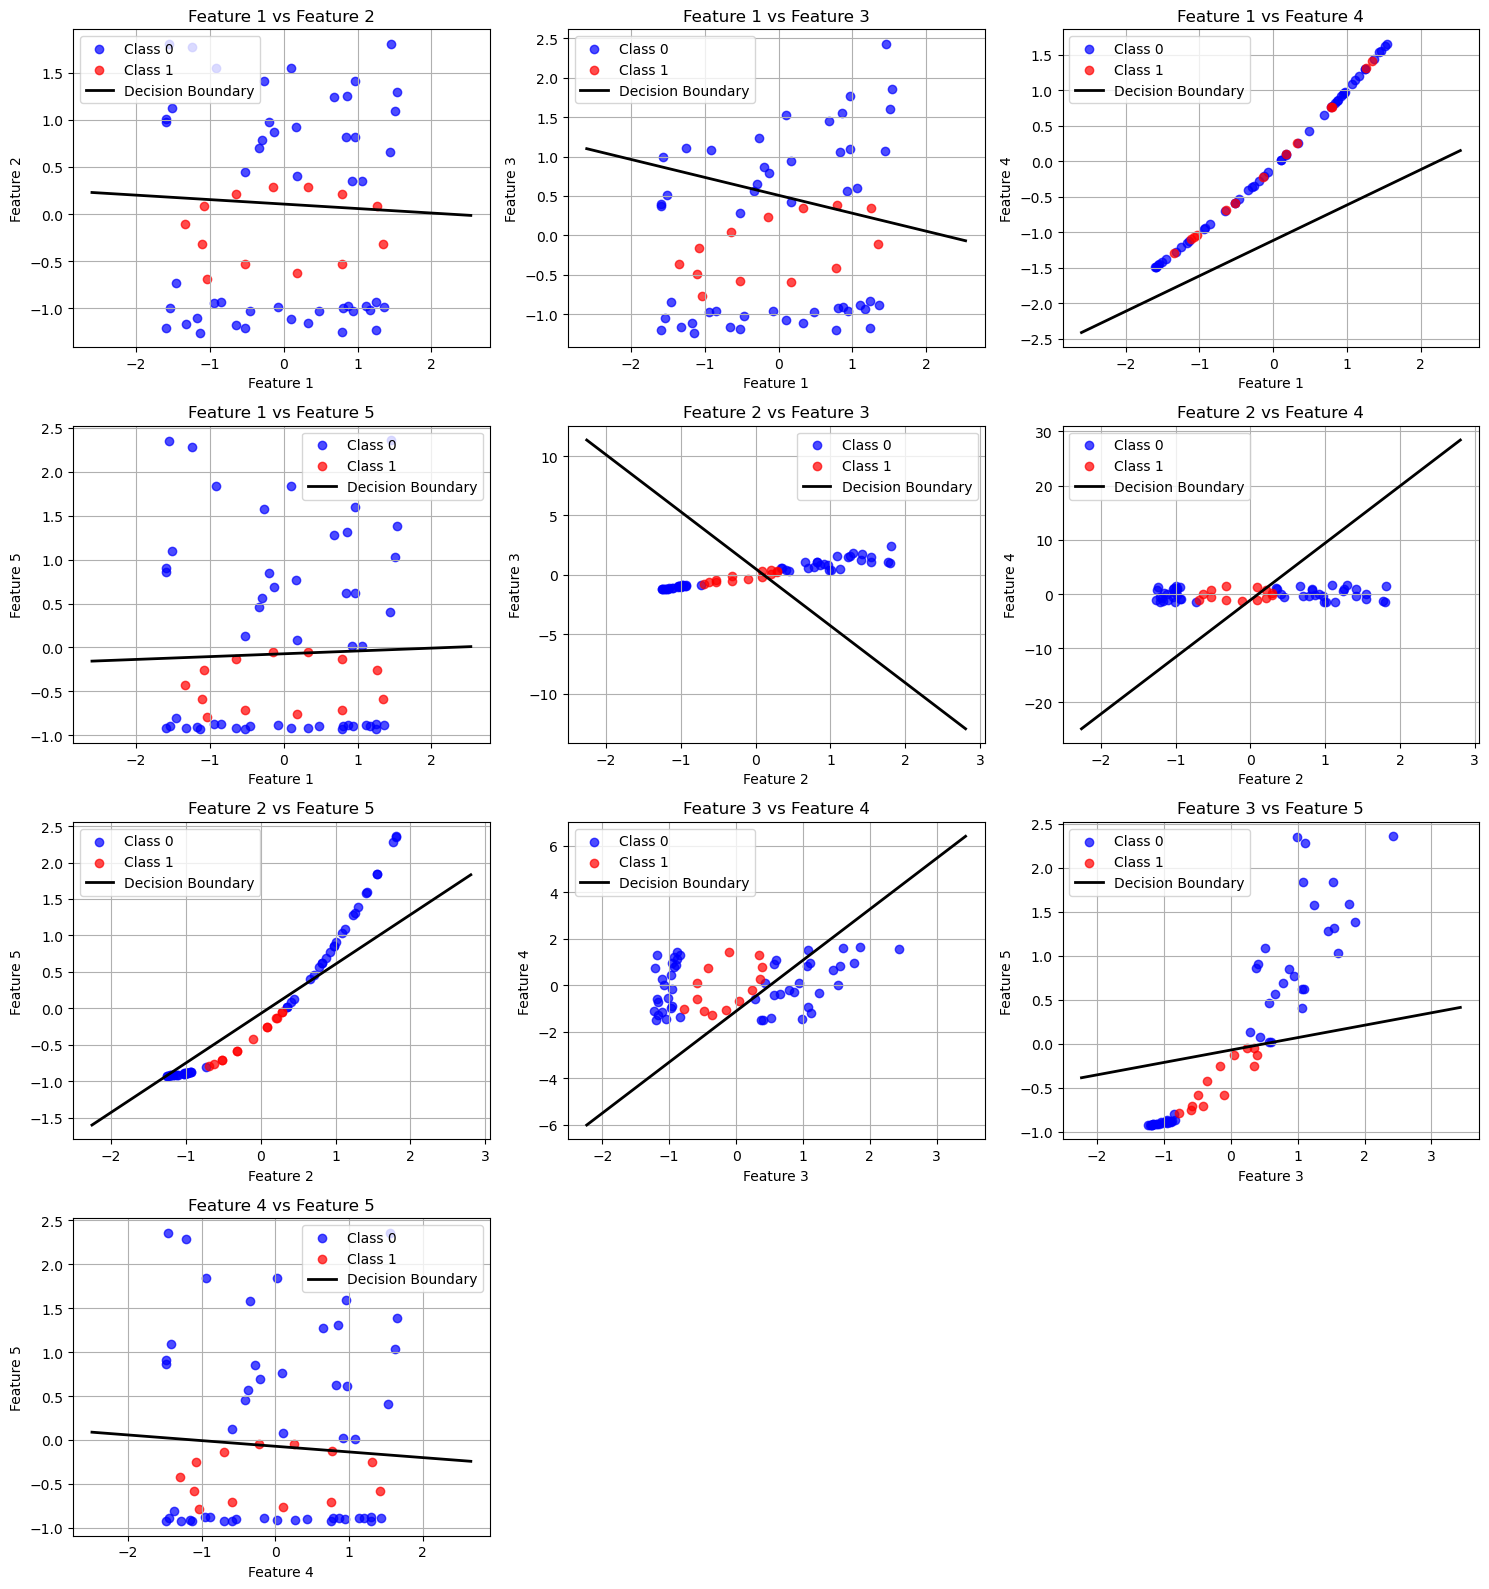

TypeError: cannot unpack non-iterable NoneType object

In [ ]:
def plot_decision_boundary(model, X_raw, y, ax=None, resolution=100, padding=0.5):
        """
        Plot the decision boundary for polynomial logistic regression.
        
        Parameters:
        - model: trained LogisticRegression model
        - X_raw: original 2D features (before polynomial transformation)
        - y: class labels
        - ax: matplotlib axis (optional)
        - resolution: number of points for mesh grid
        - padding: padding around data range
        """
        if ax is None:
            fig, ax = plt.subplots(figsize=(10, 8))
        
        # Get the range of x₁ and x₂
        x1_min, x1_max = x_train[:, 0].min() - padding, X_raw[:, 0].max() + padding
        x2_min, x2_max = x_train[:, 1].min() - padding, X_raw[:, 1].max() + padding
        
        # Create a mesh grid
        xx1, xx2 = np.meshgrid(
            np.linspace(x1_min, x1_max, resolution),
            np.linspace(x2_min, x2_max, resolution)
        )
        
        # Create feature matrix for all points in the mesh
        X_mesh_raw = np.c_[xx1.ravel(), xx2.ravel()]
        
        # Predict for all points in the mesh
        Z = model.predict(X_mesh)
        Z = Z.reshape(xx1.shape)
        
        # Plot the decision boundary
        ax.contourf(xx1, xx2, Z, alpha=0.3, cmap=plt.cm.coolwarm)
        ax.contour(xx1, xx2, Z, [0.5], colors='k', linewidths=2)
        
        # Plot the data points
        for cls in np.unique(y):
            idx = (y == cls)
            ax.scatter(
                X_raw[idx, 0], X_raw[idx, 1],
                c='r' if cls == 1 else 'b', 
                label=f'Class {cls}',
                edgecolors='k', s=50
            )
        
        ax.set_xlabel('Feature x₁')
        ax.set_ylabel('Feature x₂')
        ax.set_title('Polynomial Logistic Regression Decision Boundary')
        ax.legend()
        
        return ax


y_pred = model.predict(x_train)
accuracy = np.sum(y_pred == y_train) / len(y_train)
    
    # Get decision boundary
ax = model.plot_decision_boundary(model, x_train[:, 0:2], y_pred)
    
    # Plot the results
plt.figure(figsize=(10, 6))
    
    # Plot the data points
plt.scatter(x_train[:, 0], x_train[:, 1], c='blue', label='Class 0')
    
    # Plot the decision boundary
plt.plot(x_boundary, y_boundary, 'g-', label='Decision Boundary')
    
plt.title(f'Logistic Regression Decision Boundary (Accuracy: {accuracy:.2f})')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)


In [ ]:
def accuracy(y_pred, y_test):
    return np.sum(y_pred==y_test)/len(y_test)
accuracy(y_pred, y_train)
y_pred

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 0,
 0]

In [ ]:
xx

array([[-1.69834313, -1.64459642, -1.59084971, ...,  1.52645955,
         1.58020626,  1.63395297],
       [-1.69834313, -1.64459642, -1.59084971, ...,  1.52645955,
         1.58020626,  1.63395297],
       [-1.69834313, -1.64459642, -1.59084971, ...,  1.52645955,
         1.58020626,  1.63395297],
       ...,
       [-1.69834313, -1.64459642, -1.59084971, ...,  1.52645955,
         1.58020626,  1.63395297],
       [-1.69834313, -1.64459642, -1.59084971, ...,  1.52645955,
         1.58020626,  1.63395297],
       [-1.69834313, -1.64459642, -1.59084971, ...,  1.52645955,
         1.58020626,  1.63395297]])

In [ ]:
x_train.shape

(63, 5)